/tmp/ipykernel_277/2819819626.py:15: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  train_df = pd.read_csv('PM_train.txt', sep=' ', header=None, names=cols_names, index_col=False)


Training the Predictive Maintenance Model...

--- Model Performance ---
Accuracy: 96.05%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3543
           1       0.89      0.83      0.86       584

    accuracy                           0.96      4127
   macro avg       0.93      0.90      0.92      4127
weighted avg       0.96      0.96      0.96      4127



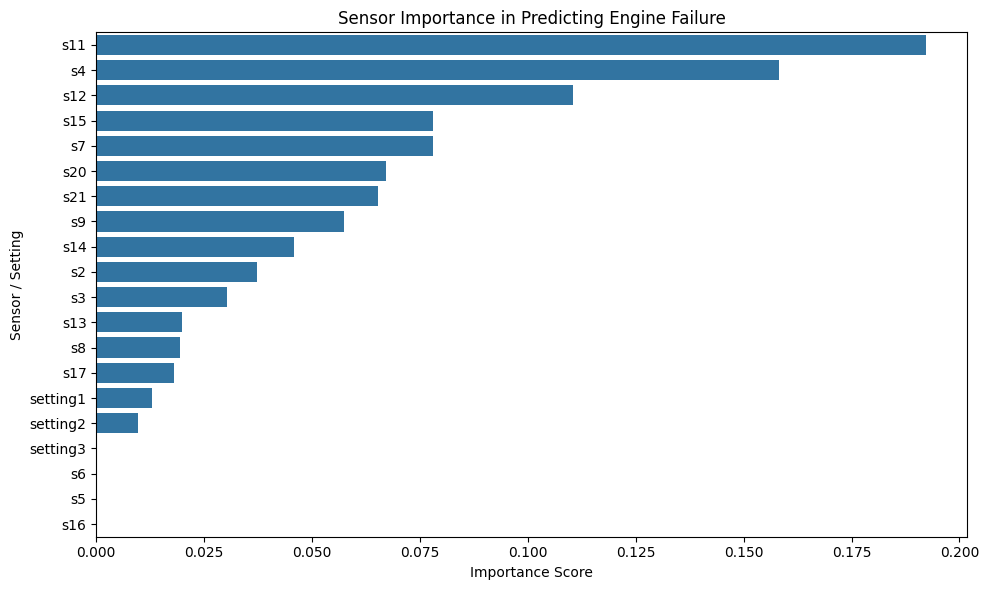

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Column Names (Standard for NASA CMAPSS dataset)
cols_names = ['id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f's{i}' for i in range(1, 22)]

# 2. Load the Training Data
# Note: Ensure the file path matches where you extracted the zip file.
# We are using the text file, but you can also load the CSV variant.
train_df = pd.read_csv('PM_train.txt', sep=' ', header=None, names=cols_names, index_col=False)

# Drop any accidental NaN columns generated by trailing spaces in the txt file
train_df.dropna(axis=1, inplace=True)

# 3. Calculate Remaining Useful Life (RUL)
# For each engine ID, find the maximum cycle (which represents the point of failure)
max_cycles = train_df.groupby('id')['cycle'].max().reset_index()
max_cycles.columns = ['id', 'max_cycle']

# Merge the max cycle back into the main dataframe
train_df = train_df.merge(max_cycles, on=['id'], how='left')

# Calculate RUL: (Max Cycle for that engine) - (Current Cycle)
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# 4. Create the Target Variable: Failure Classification
# We will predict if the engine will fail within the next 30 cycles (1 = Yes, 0 = No)
w1 = 30
train_df['label_failure_within_30'] = np.where(train_df['RUL'] <= w1, 1, 0)

# 5. Feature Selection
# Some sensors in this dataset do not change value at all (they are constant).
# We remove them to reduce noise. (Typically sensors 1, 10, 18, 19).
features_to_drop = ['id', 'cycle', 'max_cycle', 'RUL', 'label_failure_within_30',
                    's1', 's10', 's18', 's19']
X = train_df.drop(columns=features_to_drop)
y = train_df['label_failure_within_30']

# 6. Train-Test Split (Standard 80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Model Initialization & Training
# Random Forest is highly effective for sensor data and handles non-linear relationships well.
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("Training the Predictive Maintenance Model...")
model.fit(X_train, y_train)

# 8. Model Evaluation
y_pred = model.predict(X_test)

print("\n--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 9. Feature Importance (Crucial for explaining to engineering teams)
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Sensor Importance in Predicting Engine Failure')
plt.xlabel('Importance Score')
plt.ylabel('Sensor / Setting')
plt.tight_layout()
plt.show()

Train Shape: (20631, 26)
Test Shape: (11939, 26)

Training Data with RUL:
   id  cycle  setting1  setting2  setting3      s1      s2       s3       s4  \
0   1      1   -0.0007   -0.0004     100.0  518.67  641.82  1589.70  1400.60   
1   1      2    0.0019   -0.0003     100.0  518.67  642.15  1591.82  1403.14   
2   1      3   -0.0043    0.0003     100.0  518.67  642.35  1587.99  1404.20   
3   1      4    0.0007    0.0000     100.0  518.67  642.35  1582.79  1401.87   
4   1      5   -0.0019   -0.0002     100.0  518.67  642.37  1582.85  1406.22   

      s5  ...      s13      s14     s15   s16  s17   s18    s19    s20  \
0  14.62  ...  2388.02  8138.62  8.4195  0.03  392  2388  100.0  39.06   
1  14.62  ...  2388.07  8131.49  8.4318  0.03  392  2388  100.0  39.00   
2  14.62  ...  2388.03  8133.23  8.4178  0.03  390  2388  100.0  38.95   
3  14.62  ...  2388.08  8133.83  8.3682  0.03  392  2388  100.0  38.88   
4  14.62  ...  2388.04  8133.80  8.4294  0.03  393  2388  100.0  38.90   



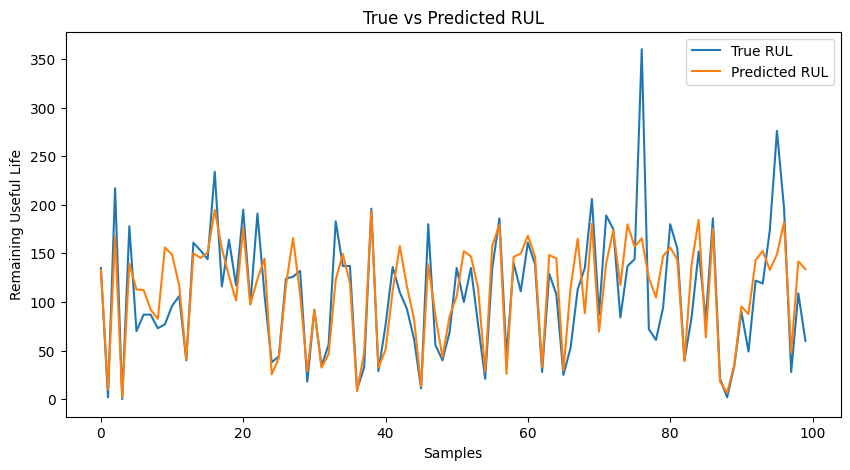


Test predictions generated successfully.


In [7]:
# ==========================================
# Turbofan Engine Remaining Useful Life (RUL)
# Complete Working Code
# ==========================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ==========================================
# 2. Load Dataset
# ==========================================

# Define column names
columns = ['id','cycle','setting1','setting2','setting3'] + [f's{i}' for i in range(1,22)]

# Load training data
train = pd.read_csv('PM_train.txt', sep=r'\s+', header=None)

# Remove extra columns if dataset has them
train = train.iloc[:, :26]

# Assign column names
train.columns = columns

# Load test data
test = pd.read_csv('PM_test.txt', sep=r'\s+', header=None)
test = test.iloc[:, :26]
test.columns = columns

# Load truth data
truth = pd.read_csv('PM_truth.txt', header=None)

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)


# ==========================================
# 3. Calculate Remaining Useful Life (RUL)
# ==========================================

max_cycle = train.groupby('id')['cycle'].max().reset_index()
max_cycle.columns = ['id','max_cycle']

train = train.merge(max_cycle, on='id')

train['RUL'] = train['max_cycle'] - train['cycle']

train.drop('max_cycle', axis=1, inplace=True)

print("\nTraining Data with RUL:")
print(train.head())


# ==========================================
# 4. Feature Selection
# ==========================================

features = train.drop(['id','cycle','RUL'], axis=1)
target = train['RUL']


# ==========================================
# 5. Feature Scaling
# ==========================================

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(features)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    target,
    test_size=0.2,
    random_state=42
)


# ==========================================
# 6. Train Machine Learning Model
# ==========================================

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)


# ==========================================
# 7. Predictions
# ==========================================

pred = model.predict(X_val)


# ==========================================
# 8. Model Evaluation
# ==========================================

rmse = np.sqrt(mean_squared_error(y_val, pred))
mae = mean_absolute_error(y_val, pred)
r2 = r2_score(y_val, pred)

print("\nModel Performance")
print("------------------")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)


# ==========================================
# 9. Feature Importance
# ==========================================

importance = model.feature_importances_

feature_names = features.columns

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Sensors:")
print(imp_df.head())


# ==========================================
# 10. Visualization
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(y_val.values[:100], label="True RUL")
plt.plot(pred[:100], label="Predicted RUL")
plt.xlabel("Samples")
plt.ylabel("Remaining Useful Life")
plt.title("True vs Predicted RUL")
plt.legend()
plt.show()


# ==========================================
# 11. Predict on Test Data
# ==========================================

test_features = test.drop(['id','cycle'], axis=1)

test_scaled = scaler.transform(test_features)

test_predictions = model.predict(test_scaled)

print("\nTest predictions generated successfully.")